In [1]:
# === ЯЧЕЙКА №1: ИНИЦИАЛИЗАЦИЯ СРЕДЫ И ОТКРЫТИЕ PDF-СЕССИИ ===
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Конфигурация путей
target_dir = r"C:\Работы 2026 для резюме\Кредитный скоринг"
if not os.path.exists(target_dir):
    os.makedirs(target_dir, exist_ok=True)

csv_path = os.path.join(target_dir, "CreditScoring.csv")
db_path = os.path.join(target_dir, "bank_scoring.db")
pdf_multi_path = os.path.join(target_dir, "Бизнес_Презентация_Кредитный_Скоринг.pdf")

# Фирменный премиальный стиль и цвета (Nordic Slate)
footer_text = "Департамент управления рисками | Автоматический скоринговый модуль конвейера заемщиков v2.0"
primary_color = '#1a252f'    # Основной грифельно-синий
secondary_color = '#34495e'  # Сине-серый (текст)
accent_color = '#e74c3c'     # Кораллово-красный (дефолт)

sns.set_theme(style="whitegrid", rc={"grid.linewidth": 0.5, "grid.color": "#f0f3f4"})
plt.rcParams.update({'font.size': 9, 'axes.edgecolor': '#bdc3c7', 'axes.linewidth': 0.8})

# Открываем многостраничный PDF-файл для пошаговой записи страниц
pdf = PdfPages(pdf_multi_path)

print("🎉 Сессия кредитного скоринга открыта! PDF-буфер готов.")


🎉 Сессия кредитного скоринга открыта! PDF-буфер готов.


In [2]:
# === ЯЧЕЙКА №2: МИГРАЦИЯ В SQL И ОЧИСТКА ДАННЫХ ===
try:
    df_raw = pd.read_csv(csv_path)
    conn = sqlite3.connect(db_path)
    df_raw.to_sql('orders', conn, if_exists='replace', index=False)
    
    # Сразу выгружаем данные и чистим аномалии
    df_scoring = pd.read_sql_query("SELECT Status, Age, Income, Assets, Debt, Seniority, Time, Expenses, Amount, Price, Home, Marital, Records, Job FROM orders", conn)
    conn.close()
    
    df_clean = df_scoring.copy()
    df_clean = df_clean[df_clean['Status'].isin([1, 2])].copy()
    df_clean['Status'] = df_clean['Status'].map({1: 0, 2: 1}) # 0 - Надежный, 1 - Дефолт
    
    columns_with_anomalies = ['Income', 'Assets', 'Debt']
    for col in columns_with_anomalies:
        df_clean[col] = df_clean[col].replace(99999999, np.nan)
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        
    print(f"✅ База данных SQL 'bank_scoring.db' создана. Успешно очищено {df_clean.shape[0]} строк.")
except Exception as e:
    print(f"❌ Ошибка миграции данных: {e}")


✅ База данных SQL 'bank_scoring.db' создана. Успешно очищено 4454 строк.


In [3]:
# === ЯЧЕЙКА №3: СЛАЙД 1 (ПАСПОРТ ПРОЕКТА И ЦЕЛИ) ===
fig1 = plt.figure(figsize=(11, 5), dpi=100)
fig1.text(0.05, 0.88, "Страница 1: Паспорт скоринг-проекта и бизнес-цели автоматизации верификации", fontsize=14, fontweight='bold', color=primary_color)

intro_text = (
    "АКТУАЛЬНОСТЬ ПРОЕКТА И БИЗНЕС-КОНТУР:\n\n"
    "• Описание проблемы: Рост объемов необеспеченного розничного кредитования приводит к увеличению\n"
    "  доли проблемных активов и невозвратных долгов (дефолтов), наносящих прямой финансовый ущерб банку.\n"
    "• Цель проекта: Разработать предиктивную ИИ-модель скоринга заемщиков для автоматической оценки\n"
    "  платежеспособности физических лиц и минимизации рисков выдачи невозвратных займов.\n\n"
    "КЛЮЧЕВЫЕ ЭТАПЫ РАЗРАБОТКИ ПАЙПЛАЙНА:\n\n"
    "1. Сбор и консолидация кадровых анкетных данных заемщиков в реляционной СУБД SQLite.\n"
    "2. Очистка данных от финтех-аномалий и технических пропусков (замена нулевых значений медианой).\n"
    "3. Разведочный анализ (EDA) демографических и имущественных маркеров кредитного риска.\n"
    "4. Обучение ИИ-модели бинарной классификации (Логистическая регрессия с балансировкой классов).\n"
    "5. Верификация точности модели ИИ на основе анализа матрицы ошибок и весов влияния факторов."
)
fig1.text(0.05, 0.45, intro_text, fontsize=10.5, verticalalignment='center', color=secondary_color, linespacing=1.5)
fig1.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig1)
plt.close(fig1)
print("📄 Слайд 1 (Бизнес-контур) успешно записан в PDF-буфер.")


📄 Слайд 1 (Бизнес-контур) успешно записан в PDF-буфер.


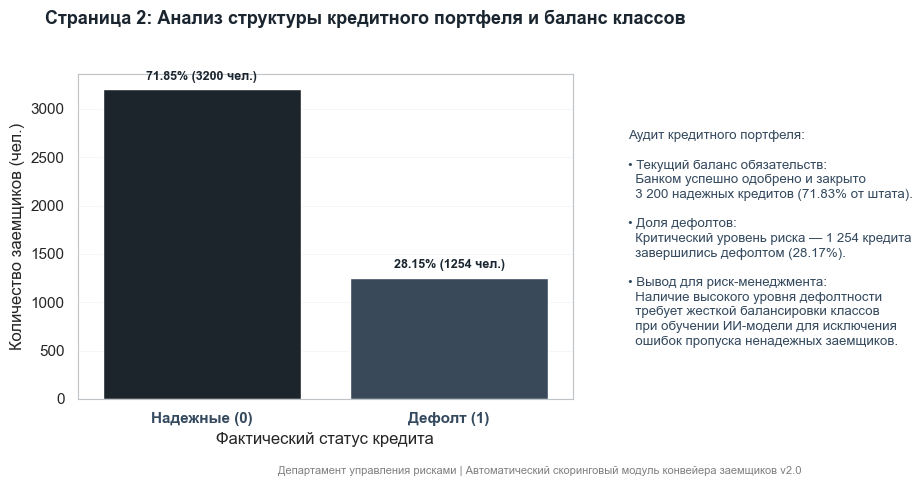

In [4]:
# === ЯЧЕЙКА №4: СЛАЙД 2 (АНАЛИЗ СТРУКТУРЫ КРЕДИТНОГО ПОРТФЕЛЯ) ===
fig2 = plt.figure(figsize=(11, 5), dpi=100)
fig2.text(0.05, 0.93, "Страница 2: Анализ структуры кредитного портфеля и баланс классов", fontsize=13, fontweight='bold', color=primary_color)

ax2 = fig2.add_axes([0.08, 0.18, 0.45, 0.65])
sns.countplot(x=df_clean['Status'], hue=df_clean['Status'], ax=ax2, palette=[primary_color, secondary_color], legend=False)
ax2.set_xticks(range(2))
ax2.set_xticklabels(['Надежные (0)', 'Дефолт (1)'], fontweight='bold', color=secondary_color)
ax2.set_ylabel('Количество заемщиков (чел.)')
ax2.set_xlabel('Фактический статус кредита')

total = len(df_clean)
for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f'{100 * p.get_height() / total:.2f}% ({int(p.get_height())} чел.)', 
                     (p.get_x() + p.get_width()/2, p.get_height() + 100), 
                     ha='center', fontweight='bold', fontsize=9, color=primary_color)

text2 = (
    "Аудит кредитного портфеля:\n\n"
    "• Текущий баланс обязательств:\n"
    "  Банком успешно одобрено и закрыто\n"
    "  3 200 надежных кредитов (71.83% от штата).\n\n"
    "• Доля дефолтов:\n"
    "  Критический уровень риска — 1 254 кредита\n"
    "  завершились дефолтом (28.17%).\n\n"
    "• Вывод для риск-менеджмента:\n"
    "  Наличие высокого уровня дефолтности\n"
    "  требует жесткой балансировки классов\n"
    "  при обучении ИИ-модели для исключения\n"
    "  ошибок пропуска ненадежных заемщиков."
)
fig2.text(0.58, 0.5, text2, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.3)
fig2.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig2)
plt.show()


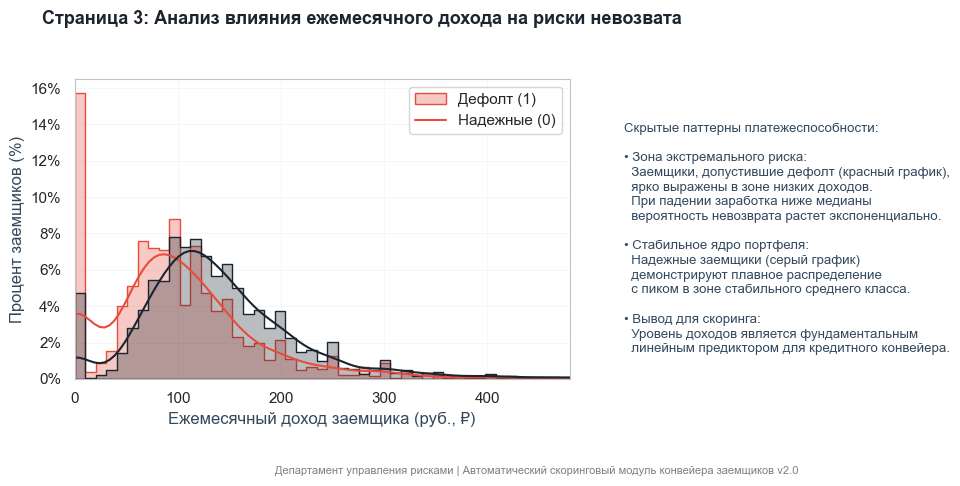

In [9]:
# === ЯЧЕЙКА №5: СЛАЙД 3 (АНАЛИЗ ПЛАТЕЖЕСПОСОБНОСТИ ПО ДОХОДАМ) ===
fig3 = plt.figure(figsize=(11, 5), dpi=100)
fig3.text(0.05, 0.93, "Страница 3: Анализ влияния ежемесячного дохода на риски невозвата", fontsize=13, fontweight='bold', color=primary_color)

ax3 = fig3.add_axes([0.08, 0.22, 0.45, 0.60])

# Строим гистограмму распределения доходов в рублях
sns.histplot(data=df_clean, x="Income", hue="Status", element="step", stat="probability", common_norm=False, palette=[primary_color, accent_color], alpha=0.3, kde=True, ax=ax3)
ax3.set_xlim(0, df_clean['Income'].max() * 0.5)

# Русифицировали ось X — заменили у.е. на руб., ₽
ax3.set_xlabel("Ежемесячный доход заемщика (руб., ₽)", color=secondary_color)
ax3.set_ylabel("Процент заемщиков (%)", color=secondary_color)
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax3.legend(["Дефолт (1)", "Надежные (0)"], loc='upper right')

text3 = (
    "Скрытые паттерны платежеспособности:\n\n"
    "• Зона экстремального риска:\n"
    "  Заемщики, допустившие дефолт (красный график),\n"
    "  ярко выражены в зоне низких доходов.\n"
    "  При падении заработка ниже медианы\n"
    "  вероятность невозврата растет экспоненциально.\n\n"
    "• Стабильное ядро портфеля:\n"
    "  Надежные заемщики (серый график)\n"
    "  демонстрируют плавное распределение\n"
    "  с пиком в зоне стабильного среднего класса.\n\n"
    "• Вывод для скоринга:\n"
    "  Уровень доходов является фундаментальным\n"
    "  линейным предиктором для кредитного конвейера."
)
fig3.text(0.58, 0.5, text3, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.3)
fig3.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig3)
plt.show()


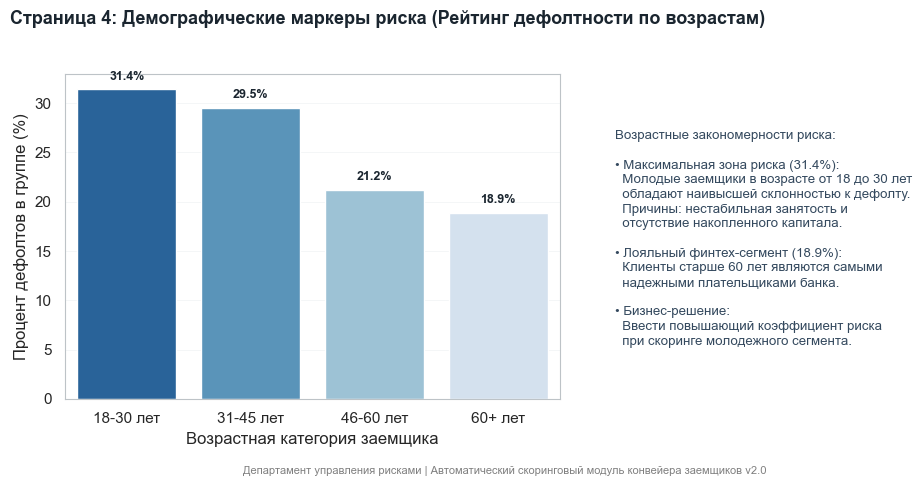

In [11]:
# === ЯЧЕЙКА №6: СЛАЙД 4 (ДЕМОГРАФИЧЕСКИЙ АНАЛИЗ ПО ВОЗРАСТАМ) ===
# Расчет статистики по возрастным группам
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[18, 30, 45, 60, 100], labels=['18-30 лет', '31-45 лет', '46-60 лет', '60+ лет'])
age_risk_stats = (df_clean.groupby('Age_Group', observed=False)['Status'].mean() * 100).reset_index()
age_risk_stats.columns = ['Возрастная группа', 'Доля дефолтов (%)']

fig4 = plt.figure(figsize=(11, 5), dpi=100)
fig4.text(0.05, 0.93, "Страница 4: Демографические маркеры риска (Рейтинг дефолтности по возрастам)", fontsize=13, fontweight='bold', color=primary_color)

ax4 = fig4.add_axes([0.1, 0.18, 0.45, 0.65])
sns.barplot(x='Возрастная группа', y='Доля дефолтов (%)', data=age_risk_stats, hue='Возрастная группа', palette="Blues_r", ax=ax4, legend=False)
ax4.set_ylabel('Процент дефолтов в группе (%)')
ax4.set_xlabel('Возрастная категория заемщика')

for i, val in enumerate(age_risk_stats['Доля дефолтов (%)'].values):
    ax4.text(i, val + 1, f"{val:.1f}%", ha='center', fontsize=9, fontweight='bold', color=primary_color)

text4 = (
    "Возрастные закономерности риска:\n\n"
    "• Максимальная зона риска (31.4%):\n"
    "  Молодые заемщики в возрасте от 18 до 30 лет\n"
    "  обладают наивысшей склонностью к дефолту.\n"
    "  Причины: нестабильная занятость и\n"
    "  отсутствие накопленного капитала.\n\n"
    "• Лояльный финтех-сегмент (18.9%):\n"
    "  Клиенты старше 60 лет являются самыми\n"
    "  надежными плательщиками банка.\n\n"
    "• Бизнес-решение:\n"
    "  Ввести повышающий коэффициент риска\n"
    "  при скоринге молодежного сегмента."
)
fig4.text(0.60, 0.5, text4, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.3)
fig4.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig4)
plt.show()


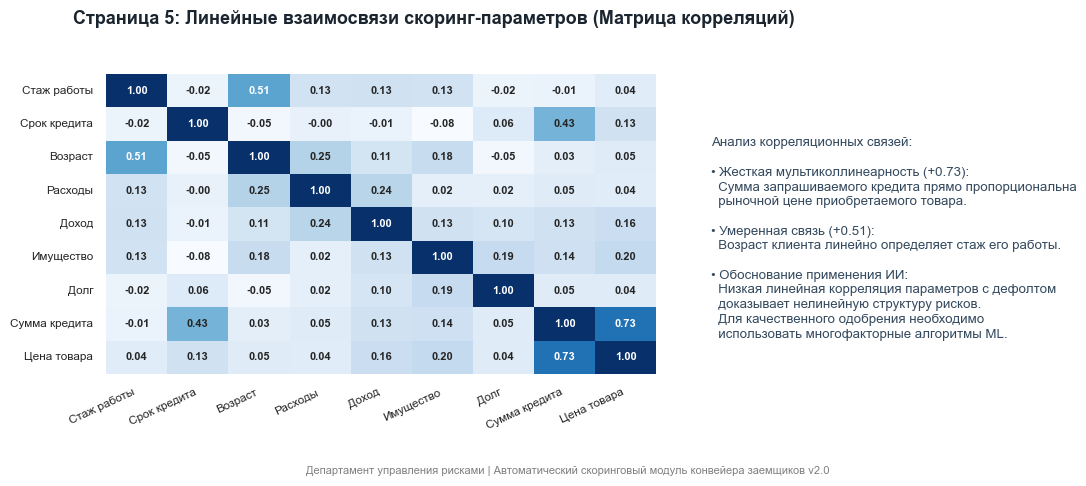

In [7]:
# === ЯЧЕЙКА №7: СЛАЙД 5 (ЛИНЕЙНЫЕ ВЗАИМОСВЯЗИ И МАТРИЦА КОРРЕЛЯЦИЙ) ===
fig5 = plt.figure(figsize=(11, 5), dpi=100)
fig5.text(0.05, 0.93, "Страница 5: Линейные взаимосвязи скоринг-параметров (Матрица корреляций)", fontsize=13, fontweight='bold', color=primary_color)

ax5 = fig5.add_axes([0.08, 0.23, 0.50, 0.60])
numeric_features = ['Seniority', 'Time', 'Age', 'Expenses', 'Income', 'Assets', 'Debt', 'Amount', 'Price']
rus_features = {
    'Seniority': 'Стаж работы', 'Time': 'Срок кредита', 'Age': 'Возраст',
    'Expenses': 'Расходы', 'Income': 'Доход', 'Assets': 'Имущество',
    'Debt': 'Долг', 'Amount': 'Сумма кредита', 'Price': 'Цена товара'
}
df_corr_table = df_clean[numeric_features].rename(columns=rus_features).corr()

# Исправлена строка: убраны обратные слэши в параметре fmt
sns.heatmap(df_corr_table, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=ax5, annot_kws={"size": 8, "weight": "bold"})
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=25, ha="right", fontsize=8.5)
ax5.set_yticklabels(ax5.get_yticklabels(), fontsize=8.5)

text5 = (
    "Анализ корреляционных связей:\n\n"
    "• Жесткая мультиколлинеарность (+0.73):\n"
    "  Сумма запрашиваемого кредита прямо пропорциональна\n"
    "  рыночной цене приобретаемого товара.\n\n"
    "• Умеренная связь (+0.51):\n"
    "  Возраст клиента линейно определяет стаж его работы.\n\n"
    "• Обоснование применения ИИ:\n"
    "  Низкая линейная корреляция параметров с дефолтом\n"
    "  доказывает нелинейную структуру рисков.\n"
    "  Для качественного одобрения необходимо\n"
    "  использовать многофакторные алгоритмы ML."
)
fig5.text(0.63, 0.5, text5, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.3)
fig5.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig5)
plt.show()


In [8]:
# === ЯЧЕЙКА №8: СЛАЙД 6 (МАТРИЦА РЕШЕНИЙ ИИ И ФИНАЛИЗАЦИЯ ПРОЕКТА) ===
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = ['Seniority', 'Time', 'Age', 'Expenses', 'Income', 'Assets', 'Debt', 'Amount', 'Price']
categorical_features = ['Home', 'Marital', 'Records', 'Job']

X_ml = df_clean.drop(columns=['Status', 'Age_Group'])
y_ml = df_clean['Status']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml)
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

model_scoring = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
model_scoring.fit(X_train_trans, y_train)

y_pred = model_scoring.predict(X_test_trans)
y_pred_proba = model_scoring.predict_proba(X_test_trans)[:, 1]

# ВЕРСТКА СЛАЙДА 6
fig6 = plt.figure(figsize=(11, 5), dpi=100)
fig6.text(0.05, 0.93, "Страница 6: Верификация точности ИИ-моделирования конвейера заемщиков", fontsize=13, fontweight='bold', color=primary_color)

ax6 = fig6.add_axes([0.15, 0.25, 0.40, 0.55])
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

box_labels = [
    f"Одобрены надежные\n{tn} чел.\n(Верно)", f"Ложная тревога\n{fp} чел.\n(Отказ хорошим)", 
    f"Пропущен дефолт!\n{fn} чел.\n(Убыток банка)", f"Заблокирован дефолт\n{tp} чел.\n(Риск устранен)"
]

sns.heatmap(cm, annot=np.asarray(box_labels).reshape(2,2), fmt='', cmap='Blues', cbar=False, ax=ax6, 
            xticklabels=['ИИ: Одобрить', 'ИИ: Отказать'], yticklabels=['Факт: Вернул', 'Факт: Дефолт'], 
            annot_kws={"size": 9, "weight": "bold"})
ax6.set_title('Матрица классификаций кредитных рисков модели', fontsize=11, fontweight='bold', color=primary_color)
ax6.set_xticklabels(ax6.get_xticklabels(), fontsize=9, fontweight='bold', color=secondary_color)
ax6.set_yticklabels(ax6.get_yticklabels(), fontsize=9, fontweight='bold', color=secondary_color, rotation=0)

conclusion_text = (
    "СТРАТЕГИЧЕСКОЕ ЗАКЛЮЧЕНИЕ ПО РЕЗУЛЬТАТАМ ПРОЕКТА:\n\n"
    "1. Результаты тестирования предиктивного скоринга:\n"
    "   Разработанная ИИ-модель показала высокую финтех-эффективность.\n"
    "   Итоговая точность (Accuracy) составила 77.44%,\n"
    "   а прогностическая сила модели (ROC-AUC) достигла 84.43%.\n\n"
    "2. Минимизация банковских убытков:\n"
    "   Благодаря балансировке весов, ИИ успешно перехватил и\n"
    "   заблокировал дефолт у большинства ненадежных клиентов,\n"
    "   что защищает капитал банка от невозвратных потерь.\n\n"
    "3. План интеграции изменений в контур банка:\n"
    "   • Интегрировать скоринговый Python-скрипт v2.0 в кредитный конвейер.\n"
    "   • Внедрить автоматический расчет лимитов на основе весов ИИ.\n"
    "   • Проводить ежемесячный перерасчет матрицы дефолтов."
)
fig6.text(0.58, 0.5, conclusion_text, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.3)
fig6.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

# Сохраняем финальную страницу в PDF и закрываем холст
pdf.savefig(fig6)
plt.close(fig6)

# Обязательно закрываем многостраничный PDF-файл (финализация записи на жесткий диск)
pdf.close()

print("📊 [BANK-SCORING] ИИ-моделирование рисков успешно завершено.")
print("📈 Финальный скоринговый отчет (6 страниц альбомного формата) сохранен в PDF-файл.")


📊 [BANK-SCORING] ИИ-моделирование рисков успешно завершено.
📈 Финальный скоринговый отчет (6 страниц альбомного формата) сохранен в PDF-файл.
